# EU Wayfair BSR 

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [9]:

sql = f"""
select * from mart.way_eu_bsr 
"""

df = bqclient.query(sql).to_dataframe()

In [11]:
print(df)

       country    category is_zinus_prod         sku  \
0           UK  mattresses             N  U110295396   
1           UK  mattresses             N  U110295396   
2           UK  mattresses             N  U110295396   
3           UK  mattresses             N  U110295396   
4           UK  mattresses             N  U110295396   
...        ...         ...           ...         ...   
202167      DE       sofas             N  D001655052   
202168      DE       sofas             N  D001655052   
202169      DE       sofas             N  D001655052   
202170      DE       sofas             N  D000446757   
202171      DE       sofas             N  D003905123   

                                              product_url  \
0                                                    None   
1                                                    None   
2                                                    None   
3                                                    None   
4                     

In [17]:
df1 = (
    df[
        (df['country'] == 'UK') &
        (df['page_label'] == 'p.1 (1~48)')
    ].copy()
)

In [21]:
df1['is_zinus_prod'] = df['is_zinus_prod'].map({'Y':1, 'N':0})

In [27]:
df1[df1['is_zinus_prod']==1]

,country,category,is_zinus_prod,sku,product_url,product_name,brand,ld_date_time,ld_date,yr_week,...,customer_price_discount_percentage,is_sponsored,has_stock,brand_oth,brand_legend_num,brand_oth_prod,brand_prod_legend_num,brand_legend_ord,brand_prod_legend_ord,page_label
13325,UK,mattresses,1,U100152323,None,Aerne Memory Foam Mattress 15cm/6in Height,Wayfair Sleep,2025-05-02 08:30:00,2025-05-02,Y25 W18,...,0.369888,0,1,Wayfair Sleep,10859,Zinus Produced,15502,3,0,p.1 (1~48)
13326,UK,mattresses,1,U100152323,None,Aerne Memory Foam Mattress 15cm/6in Height,Wayfair Sleep,2025-05-19 08:30:00,2025-05-19,Y25 W21,...,NaN,0,1,Wayfair Sleep,10859,Zinus Produced,15502,3,0,p.1 (1~48)
13327,UK,mattresses,1,U100152323,None,Aerne Memory Foam Mattress 15cm/6in Height,Wayfair Sleep,2025-05-07 08:30:00,2025-05-07,Y25 W19,...,0.383588,0,1,Wayfair Sleep,10859,Zinus Produced,15502,3,0,p.1 (1~48)
13328,UK,mattresses,1,U100152323,None,Aerne Memory Foam Mattress 15cm/6in Height,Wayfair Sleep,2025-07-29 08:30:00,2025-07-29,Y25 W31,...,0.072006,1,1,Wayfair Sleep,10859,Zinus Produced,15502,3,0,p.1 (1~48)
13329,UK,mattresses,1,U100152323,None,Aerne Memory Foam Mattress 15cm/6in Height,Wayfair Sleep,2025-07-28 08:30:00,2025-07-28,Y25 W31,...,0.072006,1,1,Wayfair Sleep,10859,Zinus Produced,15502,3,0,p.1 (1~48)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144817,UK,mattresses,1,U110418244,https://www.wayfair.co.uk/textiles-bedding/pdp...,Tight Top pocket spring mattress - Medium firm...,White Noise,2024-12-23 08:30:00,2024-12-23,Y24 W52,...,0.155750,1,1,White Noise,13476,Zinus Produced,15502,1,0,p.1 (1~48)
144819,UK,mattresses,1,U110418244,https://www.wayfair.co.uk/textiles-bedding/pdp...,Tight Top pocket spring mattress - Medium firm...,White Noise,2024-12-22 08:30:00,2024-12-22,Y24 W52,...,NaN,1,1,White Noise,13476,Zinus Produced,15502,1,0,p.1 (1~48)
144831,UK,mattresses,1,U110418244,https://www.wayfair.co.uk/textiles-bedding/pdp...,Tight Top pocket spring mattress - Medium firm...,White Noise,2025-01-28 08:30:00,2025-01-28,Y25 W05,...,0.161031,1,1,White Noise,13476,Zinus Produced,15502,1,0,p.1 (1~48)
144837,UK,mattresses,1,U110418244,https://www.wayfair.co.uk/textiles-bedding/pdp...,Tight Top pocket spring mattress - Medium firm...,White Noise,2025-02-03 08:30:00,2025-02-03,Y25 W06,...,0.161031,1,1,White Noise,13476,Zinus Produced,15502,1,0,p.1 (1~48)


In [29]:
# category, yr_week별 집계
zinus_share = (
    df1.groupby(['category', 'yr_week'], as_index=False)
      .agg(
          total_count = ('is_zinus_prod', 'count'),   # 전체 행 개수
          zinus_count = ('is_zinus_prod', 'sum')      # is_zinus_prod=1 개수
      )
      .assign(
          zinus_ratio = lambda x: x['zinus_count'] / x['total_count']  # 비율 계산
      )
      .sort_values(['category', 'yr_week'])
)

print(zinus_share)

    category  yr_week  total_count  zinus_count  zinus_ratio
0       beds  Y24 W50           96           44     0.458333
1       beds  Y24 W51          336          151     0.449405
2       beds  Y24 W52          336          144     0.428571
3       beds  Y25 W01          336          138     0.410714
4       beds  Y25 W02          288          130     0.451389
..       ...      ...          ...          ...          ...
103    sofas  Y25 W29          336           33     0.098214
104    sofas  Y25 W30          336           40     0.119048
105    sofas  Y25 W31          336           36     0.107143
106    sofas  Y25 W32          336           27     0.080357
107    sofas  Y25 W33          144            9     0.062500

[108 rows x 5 columns]


In [35]:
print(zinus_share[zinus_share['category']=='beds'])

   category  yr_week  total_count  zinus_count  zinus_ratio
0      beds  Y24 W50           96           44     0.458333
1      beds  Y24 W51          336          151     0.449405
2      beds  Y24 W52          336          144     0.428571
3      beds  Y25 W01          336          138     0.410714
4      beds  Y25 W02          288          130     0.451389
5      beds  Y25 W03          336          138     0.410714
6      beds  Y25 W04          336          116     0.345238
7      beds  Y25 W05          336          141     0.419643
8      beds  Y25 W06          336          136     0.404762
9      beds  Y25 W07          336          134     0.398810
10     beds  Y25 W08          336          130     0.386905
11     beds  Y25 W09          336          132     0.392857
12     beds  Y25 W10          336           95     0.282738
13     beds  Y25 W11          288           88     0.305556
14     beds  Y25 W12          288           68     0.236111
15     beds  Y25 W13          336       

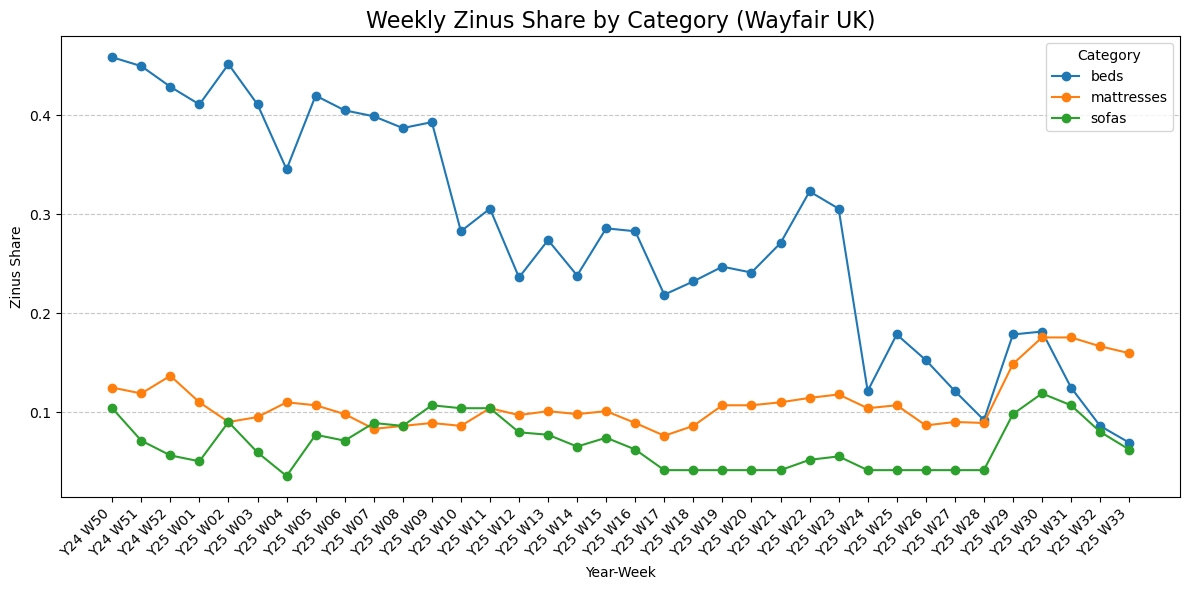

In [37]:
# 그래프 크기 설정
plt.figure(figsize=(12, 6))

# 카테고리별로 선 그래프 그리기
for cat, group in zinus_share.groupby('category'):
    plt.plot(group['yr_week'], group['zinus_ratio'], marker='o', label=cat)

# 그래프 꾸미기
plt.title('Weekly Zinus First Page Share on Wayfair UK)', fontsize=16)
plt.xlabel('Year-Week')
plt.ylabel('Zinus Share')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Category')
plt.tight_layout()

plt.show()